In [1]:
# Show plots inline, and load main getdist plot module and samples class
%matplotlib inline
%config InlineBackend.figure_format = 'retina'
%load_ext autoreload
%autoreload 1
# import libraries:
import sys, os
os.environ['TF_USE_LEGACY_KERAS'] = '1'  # needed for tensorflow KERAS compatibility
os.environ['DISPLAY'] = 'inline'  # hack to get getdist working
sys.path.insert(0,os.path.realpath(os.path.join(os.getcwd(),'../..')))
from getdist import plots, MCSamples
from getdist.gaussian_mixtures import GaussianND
import getdist
getdist.chains.print_load_details = False
import scipy
import matplotlib.pyplot as plt
import IPython
import numpy as np
# tensiometer imports:
from tensiometer import utilities
from tensiometer import gaussian_tension

In [2]:
# Create the two toy chains and the joint chain:
ndim = 2 # number of dimensions
nsamp = 10000 # number of samples
nchains = 8 # number of chains
# helper function to compute the likelihood:
def helper_gaussian_log_like( samps, mean, invcov ):
    _diff = samps-mean
    return (_diff.dot(invcov)*_diff).sum(axis=1)
# first data set:
mean_1 = np.array([0., 0.])
cov_1 = np.array([[1, -0.9], [-0.9, 1]])
samps_1 = np.random.multivariate_normal(mean_1, cov_1, size=nchains*nsamp)
log_like_1 = helper_gaussian_log_like(samps_1, mean_1, np.linalg.inv(cov_1))
# second data set:
mean_2 = np.array([1., 1.])
cov_2 = np.array([[.09, 0.], [0., .09]])
samps_2 = np.random.multivariate_normal( mean_2, cov_2, size=nchains*nsamp)
log_like_2 = helper_gaussian_log_like(samps_2, mean_2, np.linalg.inv(cov_2))
# joint data set:
cov_12 = np.linalg.inv(np.linalg.inv(cov_1) + np.linalg.inv(cov_2))
mean_12 = np.dot(cov_12, np.dot(np.linalg.inv(cov_1), mean_1) + np.dot(np.linalg.inv(cov_2), mean_2))
samps_12 = np.random.multivariate_normal(mean_12, cov_12, size=nchains*nsamp)
log_like_12 = helper_gaussian_log_like(samps_12, mean_1, np.linalg.inv(cov_1)) \
            + helper_gaussian_log_like(samps_12, mean_2, np.linalg.inv(cov_2))
# initialize the parameter names:
names = ["p%s"%i for i in range(ndim)]
labels = ["p_%s"%i for i in range(ndim)]
# initialize the GetDist chains:
chain_1 = MCSamples(samples=samps_1, loglikes=log_like_1, names=names, labels=labels, label='first')
chain_2 = MCSamples(samples=samps_2, loglikes=log_like_2, names=names, labels=labels, label='second')
chain_12 = MCSamples(samples=samps_12, loglikes=log_like_12, names=names, labels=labels, label='joint')
# separate the chains so that we can have rough convergence estimates:
for chain in [chain_1, chain_2, chain_12]:
    chain.chain_offsets = [i*nsamp for i in range(nchains+1)]

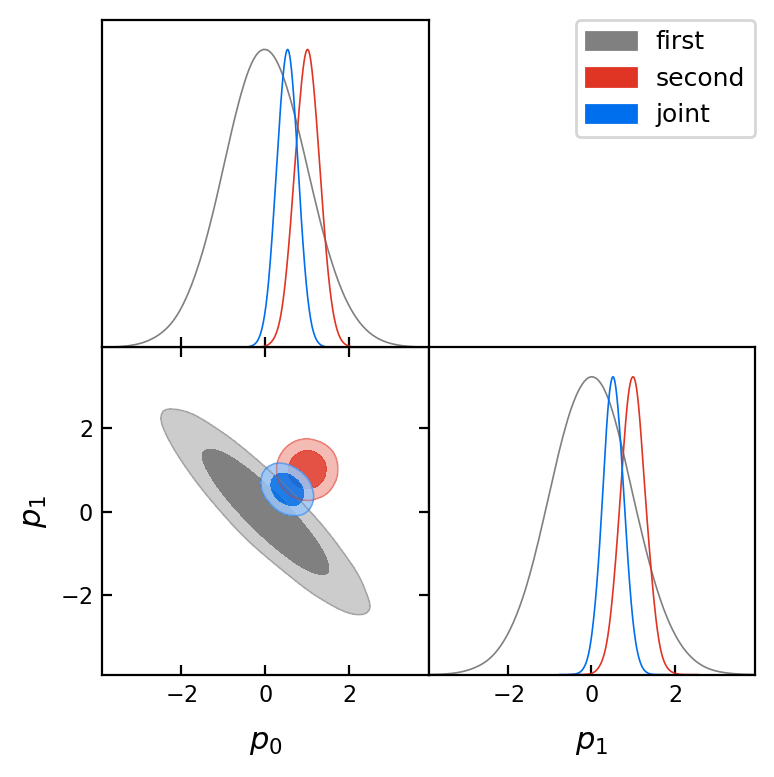

In [3]:
g = plots.get_subplot_plotter()
g.triangle_plot([chain_1, chain_2, chain_12], filled=True)

In [4]:
# calculate Q_DM and its dofs:
Q_DM, Q_DM_dofs = gaussian_tension.Q_DM( chain_1, chain_2 )
# calculate probability to exceed:
Q_DM_P = scipy.stats.chi2.cdf(Q_DM, Q_DM_dofs)
# print everything:
print(f'Q_DM = {Q_DM:.2f}, dofs = {Q_DM_dofs:2}, P = {Q_DM_P:.5f}')

Q_DM = 10.48, dofs =  2, P = 0.99471


In [5]:
# convert to effective number of sigmas:
Q_DM_nsigma = utilities.from_confidence_to_sigma(Q_DM_P)
# print everything:
print(f'nsigma = {Q_DM_nsigma:.3f}')

nsigma = 2.789


In [51]:
import sys
sys.path.append('../python')
import utils
import threepoint
from getdist import loadMCSamples

In [52]:
# load the samples (remove no burn in since the example chains have already been cleaned):
planckdir = '../data/COM_CosmoParams_base-plikHM-TTTEEE-lowl-lowE_R3.00/base/plikHM_TTTEEE_lowl_lowE/'
desdir = '../output/blind-metacal-8arcmincut-december/'
# the Planck 2018 TTTEEE chain:
chain_2 = utils.read_cosmosis_mcmc_des_chain(desdir+'des-y3-2pt-map3-all-blind-metacal.txt', to_mcsamples=True, blind=False)
#chain_1 = getdist.mcsamples.loadMCSamples(planckdir+'base_plikHM_TTTEEE_lowl_lowE_1.txt', no_cache=True)
# 2pt only chain:
chain_3 = utils.read_cosmosis_mcmc_des_chain('../output/blind-metacal-updatedcov/des-y3-2pt-blind-metacal-simcov.txt', to_mcsamples=True, blind=False)

#chain_2 = MCSamples(desdir+'des-y3-2pt-map3-all-blind-metacal.txt')
try:
    chain_1 = loadMCSamples(planckdir+'base_plikHM_TTTEEE_lowl_lowE')
    if chain_1 is None:
        print("Error: Chain object is None. Check file paths and formats.")
    else:
        print("Chain loaded successfully!")
except Exception as e:
    print("Error loading chain:", e)
#chain_1 = utils.read_cosmosis_mcmc_chain(planckdir+'base_plikHM_TTTEEE_lowl_lowE_1.txt', to_mcsamples=True, blind=False)

Chain loaded successfully!


omegabh2	\Omega_b h^2
omegach2	\Omega_c h^2
theta	100\theta_{MC}
tau	\tau
logA	{\rm{ln}}(10^{10} A_s)
ns	n_s
calPlanck	y_{\rm cal}
acib217	A^{CIB}_{217}
xi	\xi^{tSZ-CIB}
asz143	A^{tSZ}_{143}
aps100	A^{PS}_{100}
aps143	A^{PS}_{143}
aps143217	A^{PS}_{143\times217}
aps217	A^{PS}_{217}
aksz	A^{kSZ}
kgal100	A^{{\rm dust}TT}_{100}
kgal143	A^{{\rm dust}TT}_{143}
kgal143217	A^{{\rm dust}TT}_{143\times217}
kgal217	A^{{\rm dust}TT}_{217}
galfTE100	A^{{\rm dust}TE}_{100}
galfTE100143	A^{{\rm dust}TE}_{100\times143}
galfTE100217	A^{{\rm dust}TE}_{100\times217}
galfTE143	A^{{\rm dust}TE}_{143}
galfTE143217	A^{{\rm dust}TE}_{143\times217}
galfTE217	A^{{\rm dust}TE}_{217}
cal0	c_{100}
cal2	c_{217}
H0*	H_0
omegal*	\Omega_\Lambda
om*	\Omega_m
omegamh2*	\Omega_m h^2
omegamh3*	\Omega_m h^3
sig8*	\sigma_8
s8*	S_8
s8omegamp5*	\sigma_8 \Omega_m^{0.5}
s8omegamp25*	\sigma_8 \Omega_m^{0.25}
s8h5*	\sigma_8/h^{0.5}
rdragh*	r_{\rm drag} h
rmsdeflect*	\langle d^2\rangle^{1/2}
zrei*	z_{\rm re}
A*	10^9 A_s
clamp*	10

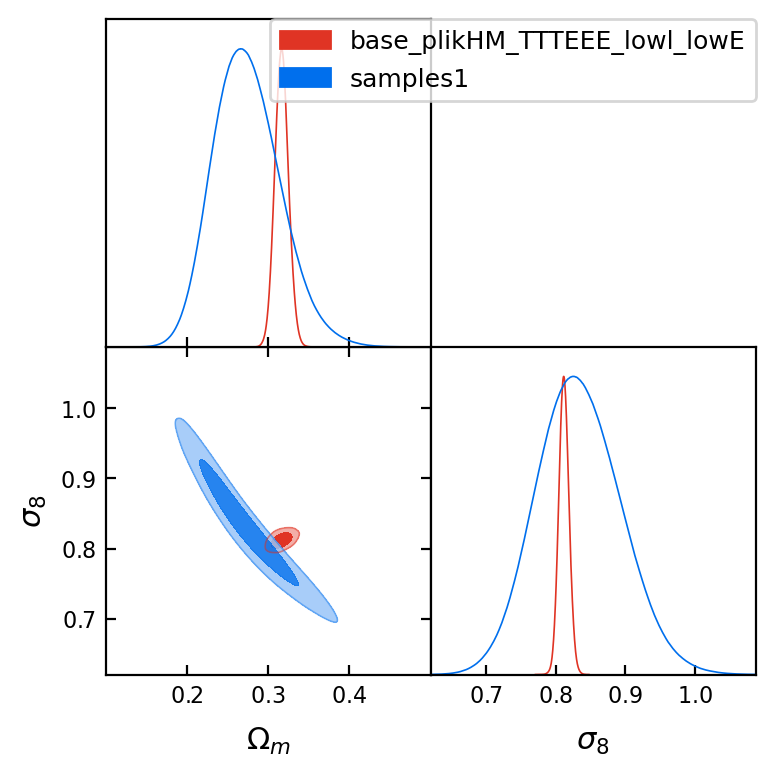

In [53]:
#shared_param_names = [name for name in chain_1.getParamNames().getRunningNames() 
#                      if name in chain_2.getParamNames().getRunningNames()]
print(chain_1.getParamNames())
print(chain_2.getParamNames())

print(chain_1.samples is None)
print(chain_2.samples is None)

g = plots.get_subplot_plotter()
g.triangle_plot([chain_1, chain_2], params=['om','sig8'], filled=True)

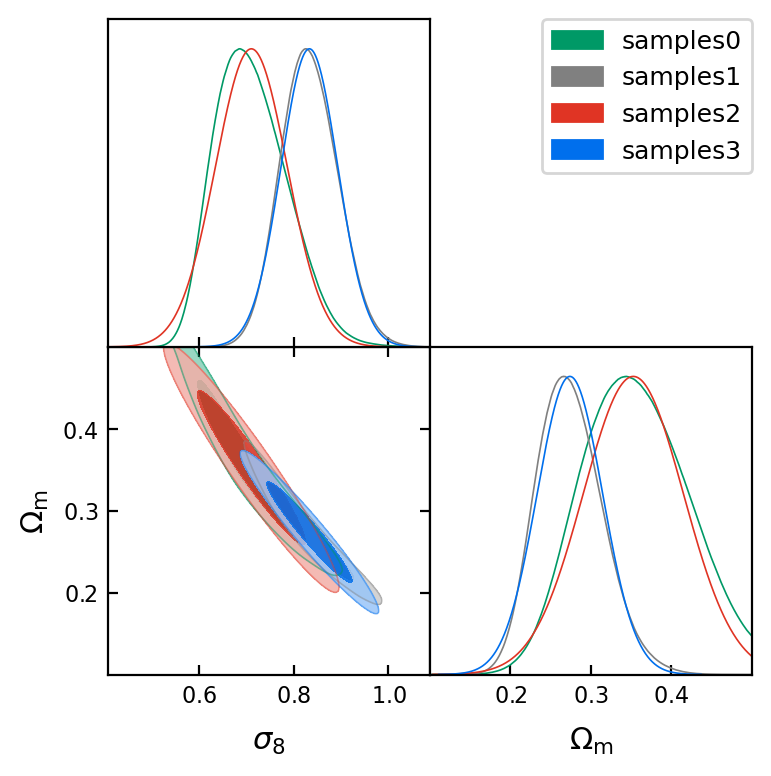

In [55]:
# get the Gaussian approximation:
gaussian_1 = gaussian_tension.gaussian_approximation(chain_1)
gaussian_2 = gaussian_tension.gaussian_approximation(chain_2)
gaussian_3 = gaussian_tension.gaussian_approximation(chain_3)
# plot for comparison:
g = plots.get_subplot_plotter()
g.triangle_plot([chain_3, chain_2, gaussian_3, gaussian_2], params=['sig8','om'], filled=True)

In [61]:
# start with Q_DM:
#Q_DM = gaussian_tension.Q_DM(chain_2, chain_3, param_names=['sig8', 'om'])
Q_DM = gaussian_tension.Q_DM(chain_2, chain_3)
# compute probability:
Q_DM_P = scipy.stats.chi2.cdf(*Q_DM)
# print results:
print(f'Using only sigma8 and Omegam: Q_DM = {Q_DM[0]:.3f} with dofs {Q_DM[1]:.3f}')
print(f'Q_DM probability = {Q_DM_P:.5f}, n_sigma = {utilities.from_confidence_to_sigma(Q_DM_P):.3f}')

LinAlgError: Eigenvalues did not converge